In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import ast
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
import re
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from catboost import CatBoostClassifier


In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [3]:
train_df = pd.read_csv('/kaggle/input/datasets/rachelbronzen/digicow/Train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/rachelbronzen/digicow/Test.csv')
submission = pd.read_csv('/kaggle/input/datasets/rachelbronzen/digicow/SampleSubmission.csv')
prior_df = pd.read_csv('/kaggle/input/datasets/rachelbronzen/digicow/Prior.csv')

In [4]:
print("Train.csv")
display(train_df.head())
print("Prior.csv")
display(prior_df.head())

Train.csv


,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list
0,ID_CENCC8,FAR_eqbhscj,2024-01-03,Female,Manual,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"
1,ID_YTO0FF,FAR_qlwtyik,2024-01-03,Female,Manual,Above 35,GRP_zemrbsy,1,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Housing'], ['Poultry Housing']]"
2,ID_1476PE,FAR_somfzxp,2024-01-03,Female,Manual,Above 35,GRP_zmblxsw,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Asili Fertilizer (Organic)', 'Biosecurity I..."
3,ID_MLKLIR,FAR_ongcqyd,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Products'], ['Record Keeping In Dai..."
4,ID_V5ZVTA,FAR_ztsbhhm,2024-01-03,Female,Ussd,Below 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"


Prior.csv


,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list
0,ID_70GP6F,FAR_leopgvh,2024-01-03,Female,Manual,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,TRA_szrwyfzz,"['Ndume App', 'Poultry Feeding']"
1,ID_IWQOWJ,FAR_vdcjfxm,2024-01-03,Female,Ussd,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,TRA_szrwyfzz,"['Ndume App', 'Poultry Feeding']"
2,ID_Z3ES85,FAR_hfkybdg,2024-01-03,Female,Manual,Above 35,GRP_zmblxsw,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,TRA_rkvyofbh,"['Asili Fertilizer (Organic)', 'Biosecurity In..."
3,ID_JNZM6R,FAR_hfkybdg,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,TRA_rkvyofbh,['Poultry Products']
4,ID_BNJ1GU,FAR_hfkybdg,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,1,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,TRA_rkvyofbh,['Record Keeping In Dairy']


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13536 entries, 0 to 13535
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       13536 non-null  object
 1   farmer_name              13536 non-null  object
 2   training_day             13536 non-null  object
 3   gender                   13536 non-null  object
 4   registration             13536 non-null  object
 5   age                      13536 non-null  object
 6   group_name               13536 non-null  object
 7   belong_to_cooperative    13536 non-null  int64 
 8   county                   13536 non-null  object
 9   subcounty                13536 non-null  object
 10  ward                     13536 non-null  object
 11  adopted_within_07_days   13536 non-null  int64 
 12  adopted_within_90_days   13536 non-null  int64 
 13  adopted_within_120_days  13536 non-null  int64 
 14  has_topic_trained_on     13536 non-nul

In [6]:
print(train_df.isnull().sum())

ID                         0
farmer_name                0
training_day               0
gender                     0
registration               0
age                        0
group_name                 0
belong_to_cooperative      0
county                     0
subcounty                  0
ward                       0
adopted_within_07_days     0
adopted_within_90_days     0
adopted_within_120_days    0
has_topic_trained_on       0
trainer                    0
topics_list                0
dtype: int64


In [7]:
prior_df['training_day'] = pd.to_datetime(prior_df['training_day'], errors='coerce')
prior_features = prior_df.groupby('farmer_name').agg(
    prior_attendance_count=('ID', 'count'),
    prior_adopt_07_rate=('adopted_within_07_days', 'mean'),
    prior_adopt_90_rate=('adopted_within_90_days', 'mean'),
    prior_adopt_120_rate=('adopted_within_120_days', 'mean'),
    prior_first_date=('training_day', 'min'),
    prior_last_date=('training_day', 'max'),
    past_trainers=('trainer', lambda x: " ".join(str(v) for v in x)) #menggabungkan semua nama trainer masa lalu
).reset_index()

#buang kolom tanggal sementara agar rapi
prior_features.drop(columns=['prior_first_date', 'prior_last_date'], inplace=True)

In [8]:
#gabungkan fitur 
train_df = pd.merge(train_df, prior_features, on='farmer_name', how='left')
test_df = pd.merge(test_df, prior_features, on='farmer_name', how='left')

In [9]:
#fitur "apakah trainer sama?" (1 = Ya, 0 = Tidak)
def check_familiar_trainer(row):
    current = str(row['trainer'])
    past = str(row['past_trainers'])
    if pd.isna(past) or past == "nan": 
        return 0 #petani baru yg belum kenal trainer
    current_clean = re.sub(r'[^a-zA-Z0-9_]', '', current)
    if current_clean in past:
        return 1
    return 0
    
train_df['is_familiar_trainer'] = train_df.apply(check_familiar_trainer, axis=1)
test_df['is_familiar_trainer'] = test_df.apply(check_familiar_trainer, axis=1)

In [10]:
num_cols_prior = [
    'prior_attendance_count', 'prior_adopt_07_rate', 
    'prior_adopt_90_rate', 'prior_adopt_120_rate', 
    'is_familiar_trainer'
]

In [11]:
#ekstrak tanggal
#ubah tipe data string jdi datetime Pandas
train_df['training_day'] = pd.to_datetime(train_df['training_day'], errors='coerce')
test_df['training_day'] = pd.to_datetime(test_df['training_day'], errors='coerce')
#ekstrak komponen waktu buat Train
train_df['training_month'] = train_df['training_day'].dt.month
train_df['training_dayofweek'] = train_df['training_day'].dt.dayofweek
train_df['training_dayofyear'] = train_df['training_day'].dt.dayofyear
#ekstrak komponen waktu buat Test
test_df['training_month'] = test_df['training_day'].dt.month
test_df['training_dayofweek'] = test_df['training_day'].dt.dayofweek
test_df['training_dayofyear'] = test_df['training_day'].dt.dayofyear
#daftar kolom waktu baru
time_cols = ['training_month', 'training_dayofweek', 'training_dayofyear']

In [12]:
STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 
    'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 
    'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 
    'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 
    'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 
    'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', 
    "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 
    'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
])

In [13]:
#mengekstrak fitur topik pelatihan
def clean_topics_deep(text):
    if pd.isna(text): return ""
    try:
        #ekstrak dari format list string
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list) and len(parsed) > 0 and isinstance(parsed[0], list):
            extracted_text = " ".join([str(item) for sublist in parsed for item in sublist])
        elif isinstance(parsed, list):
            extracted_text = " ".join([str(item) for item in parsed])
        else:
            extracted_text = str(text)
            
        #hapus tanda baca dan ubah jadi huruf kecil semua
        cleaned_text = re.sub(r'[^\w\s]', ' ', extracted_text).lower()
        
        #buang kata hubung (stopwords) dan spasi berlebih
        words = cleaned_text.split()
        final_words = [word for word in words if word not in STOPWORDS]
        return " ".join(final_words)
        
    except:
        cleaned = re.sub(r'[^\w\s]', ' ', str(text)).lower()
        return " ".join([w for w in cleaned.split() if w not in STOPWORDS])

train_df['clean_topics'] = train_df['topics_list'].apply(clean_topics_deep)
test_df['clean_topics'] = test_df['topics_list'].apply(clean_topics_deep)
prior_df['trainer'] = prior_df['trainer'].apply(clean_topics_deep)

In [14]:
#ambil 20 topik paling krusial
tfidf = TfidfVectorizer(max_features=50) 
train_topics = tfidf.fit_transform(train_df['clean_topics'])
test_topics = tfidf.transform(test_df['clean_topics'])

#buat nama kolom baru
topic_cols = [f"topic_{i}" for i in range(50)]

#gabungkan kolom topik ini ke dalam DataFrame utama
train_topics_df = pd.DataFrame(train_topics.toarray(), columns=topic_cols)
test_topics_df = pd.DataFrame(test_topics.toarray(), columns=topic_cols)

train_df = pd.concat([train_df, train_topics_df], axis=1)
test_df = pd.concat([test_df, test_topics_df], axis=1)

In [15]:
#hitung elemen instruktur
def count_trainers(text):
    text_str = str(text).strip()
    if text_str == 'nan' or text_str == 'Missing' or pd.isna(text) or text_str == "":
        return 0
    
    #jika formatnya masih berupa list mentah: "['TRA_A', 'TRA_B']"
    if '[' in text_str and ']' in text_str:
        return text_str.count(',') + 1
        
    #jika sudah dibersihkan menjadi string: "TRA_A TRA_B"
    return len(text_str.split())

train_df['num_trainers'] = train_df['trainer'].apply(count_trainers)
test_df['num_trainers'] = test_df['trainer'].apply(count_trainers)

In [16]:
train_df['age'] = pd.to_numeric(train_df['age'], errors='coerce')
test_df['age'] = pd.to_numeric(test_df['age'], errors='coerce')

In [17]:
cat_cols = ["gender", "registration", "group_name", "trainer", "belong_to_cooperative", "county", "subcounty", "ward"]
time_cols = ['training_month', 'training_dayofweek', 'training_dayofyear']
num_cols = num_cols_prior + time_cols + topic_cols + ['num_trainers', 'age']
feature_cols = cat_cols + num_cols
    
X = train_df[feature_cols]
X_test_final = test_df[feature_cols]

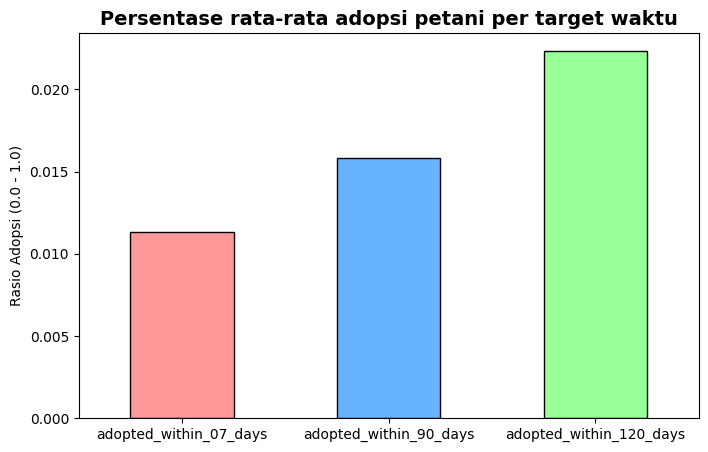


Tabulasi Silang (Membuktikan Chain Reaction 7 Hari ke 90 Hari):
Adopsi 90 Hari      0    1
Adopsi 07 Hari            
0               13322   61
1                   0  153
--------------------------------------------------

Tabulasi Silang (Membuktikan Chain Reaction 90 Hari ke 120 Hari):
Adopsi 120 Hari      0    1
Adopsi 90 Hari             
0                13234   88
1                    0  214
--------------------------------------------------


In [18]:
#DISTRIBUSI TARGET 
targets = ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']

plt.figure(figsize=(8, 5))
train_df[targets].mean().plot(kind='bar', color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
plt.title('Persentase rata-rata adopsi petani per target waktu', fontsize=14, fontweight='bold')
plt.ylabel('Rasio Adopsi (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.show()

print("\nTabulasi Silang (Membuktikan Chain Reaction 7 Hari ke 90 Hari):")
print(pd.crosstab(train_df['adopted_within_07_days'], train_df['adopted_within_90_days'], 
                  rownames=['Adopsi 07 Hari'], colnames=['Adopsi 90 Hari']))
print("-" * 50)

print("\nTabulasi Silang (Membuktikan Chain Reaction 90 Hari ke 120 Hari):")
print(pd.crosstab(train_df['adopted_within_90_days'], train_df['adopted_within_120_days'], 
                  rownames=['Adopsi 90 Hari'], colnames=['Adopsi 120 Hari']))
print("-" * 50)

Tabulasi Silang
Tidak ada satu pun petani yang mengadopsi di 7 hari tapi gagal di 90 hari (0 kasus).
Tidak ada satu pun yang mengadopsi di 90 hari tapi gagal di 120 hari (0 kasus).
Insight: Ini adalah rantai sebab-akibat yang 100% mutlak.

Persentase rata-rata adopsi petani per target waktu
Insight: Dataset ini mengalami Extreme Class Imbalance. Dari 100 petani, mungkin hanya 1 atau 2 yang mempraktikkan ilmu.

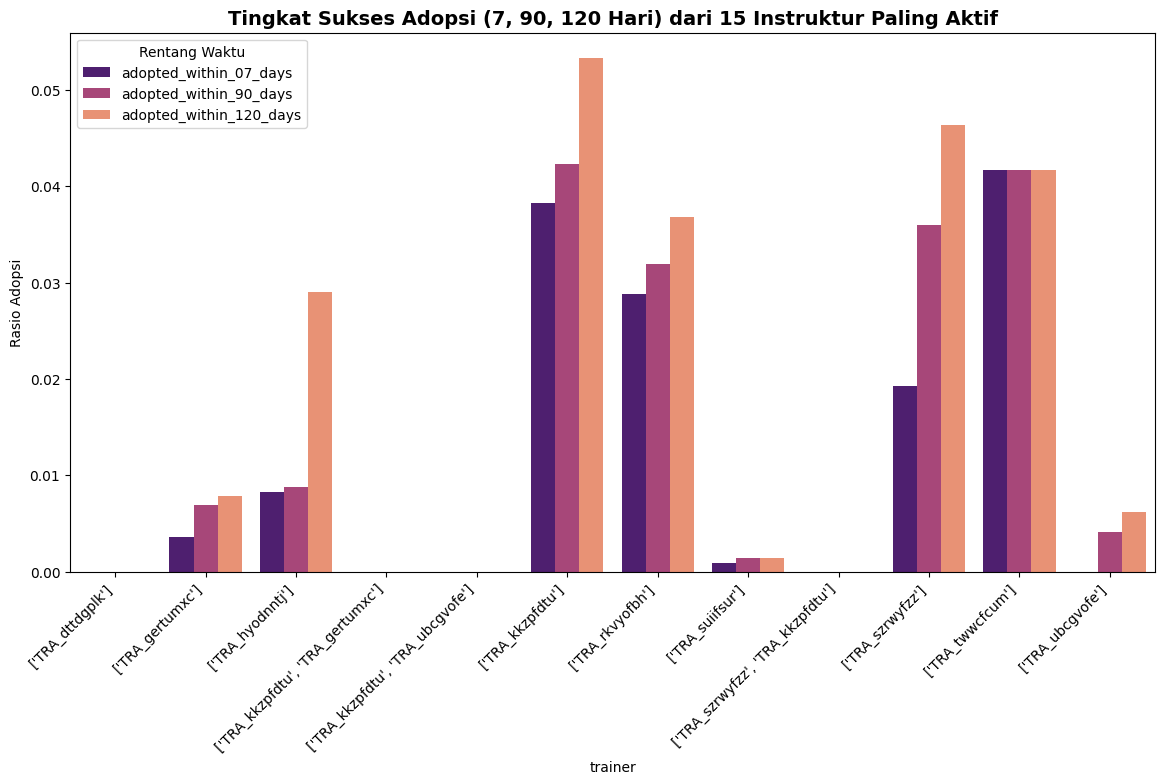

In [19]:
#15 Instruktur dengan murid paling banyak
top_trainers = train_df['trainer'].value_counts().nlargest(15).index
df_top_trainers = train_df[train_df['trainer'].isin(top_trainers)]

#rata-rata ketiga target untuk 15 pelatih top
trainer_stats = df_top_trainers.groupby('trainer')[targets].mean().reset_index()

trainer_stats_melted = trainer_stats.melt(id_vars='trainer', var_name='Target Waktu', value_name='Rasio Adopsi')

plt.figure(figsize=(14, 7))
sns.barplot(data=trainer_stats_melted, x='trainer', y='Rasio Adopsi', hue='Target Waktu', palette='magma')
plt.title('Tingkat Sukses Adopsi (7, 90, 120 Hari) dari 15 Instruktur Paling Aktif', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rentang Waktu')
plt.show()

Instruktur bernama TRA_kkzpfdtu (berdiri sendiri). Tiang batangnya sangat tinggi (rasio adopsi tembus 0.04 - 0.05). Ada kombinasi TRA_kkzpfdtu TRA_gertumxc dan TRA_kkzpfdtu TRA_ubcgvofe. Tiang kosong. Bukti bahwa tidak boleh membersihkan atau memotong kolom trainer. Biarkan formatnya kotor seperti di Golden Baseline (awal), karena model butuh tahu apakah pelatih itu mengajar sendirian atau berdua.

Jika mengajar sendirian, petani sukses. Tapi jika dia mengajar berdua dengan pelatih lain (asisten), tingkat keberhasilannya malah hancur jadi 0%. 

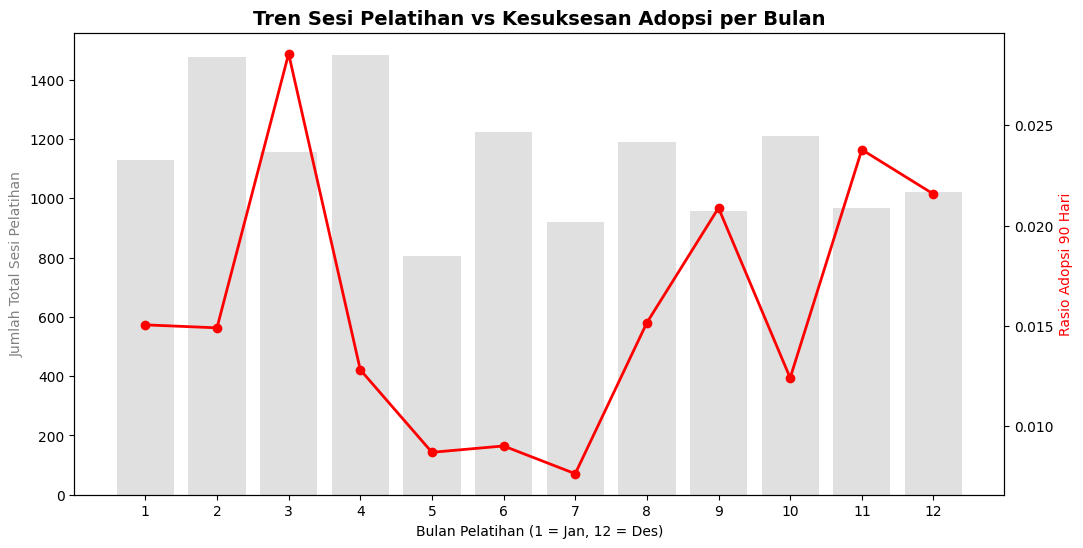

In [20]:
#ANALISIS TEMPORAL(Efek Musim)
monthly_stats = train_df.groupby('training_month').agg(
    total_pelatihan=('ID', 'count'),
    adopsi_90_hari=('adopted_within_90_days', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx() #membuat dua sumbu Y

#bar chart untuk jumlah pelatihan
ax1.bar(monthly_stats['training_month'], monthly_stats['total_pelatihan'], color='lightgray', alpha=0.7, label='Total Sesi')
#line chart untuk tingkat adopsi
ax2.plot(monthly_stats['training_month'], monthly_stats['adopsi_90_hari'], color='red', marker='o', linewidth=2, label='Tingkat Adopsi')

ax1.set_xlabel('Bulan Pelatihan (1 = Jan, 12 = Des)')
ax1.set_ylabel('Jumlah Total Sesi Pelatihan', color='gray')
ax2.set_ylabel('Rasio Adopsi 90 Hari', color='red')
plt.title('Tren Sesi Pelatihan vs Kesuksesan Adopsi per Bulan', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13))
plt.show()

Pola Musim Tanam (Seasonality) yang Ekstrem: Tingkat adopsi (garis merah) tidak stabil, melainkan memiliki lonjakan dramatis di bulan-bulan tertentu. Bulan 3 (Maret) adalah puncak absolut, lalu bulan 9, 11, dan 12. Sebaliknya, Bulan 5 dan 7 adalah "bulan mati" di mana petani malas mempraktikkan ilmu. * Kuantitas ≠ Kualitas: Pada Bulan 4. Jumlah sesinya sangat tinggi (batang abu-abu tinggi), tapi tingkat adopsinya terjun bebas. Artinya, pelatih rajin mengajar di bulan 4, tapi karena mungkin salah musim (misal: masuk musim kemarau), petani tidak mau mempraktikkannya.

Insight: Petani tidak peduli seberapa sering pelatih datang. mereka hanya akan mempraktikkan ilmu jika waktunya (musimnya) tepat.

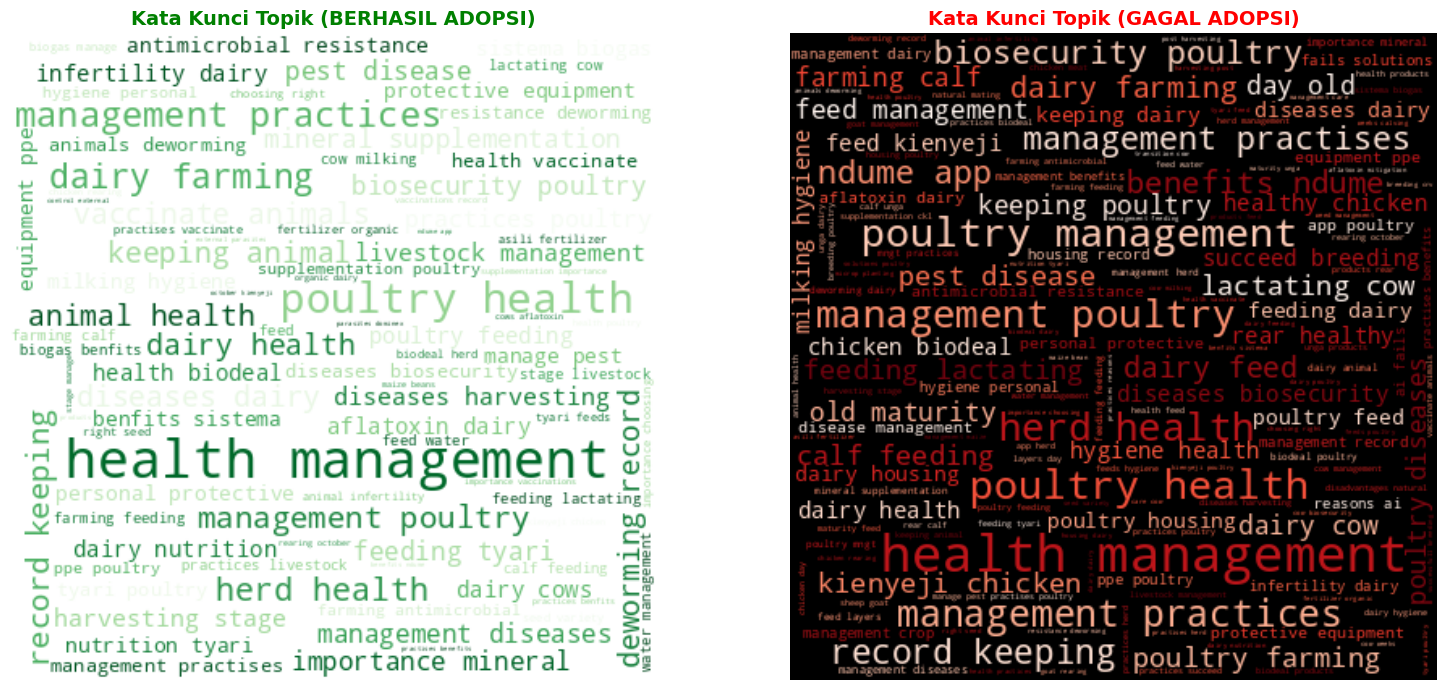

In [21]:
#ANALISIS TEKS NLP (Topik Favorit)
#menggabungkan semua teks topik berdasarkan target
text_adopted = " ".join(train_df[train_df['adopted_within_90_days'] == 1]['clean_topics'].dropna())
text_failed = " ".join(train_df[train_df['adopted_within_90_days'] == 0]['clean_topics'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#wordcloud untuk yang berhasil Adopsi
wc_adopted = WordCloud(width=400, height=400, background_color='white', colormap='Greens').generate(text_adopted)
axes[0].imshow(wc_adopted, interpolation='bilinear')
axes[0].set_title('Kata Kunci Topik (BERHASIL ADOPSI)', fontsize=14, fontweight='bold', color='green')
axes[0].axis('off')

#wordcloud untuk yang Gagal Adopsi
wc_failed = WordCloud(width=400, height=400, background_color='black', colormap='Reds').generate(text_failed)
axes[1].imshow(wc_failed, interpolation='bilinear')
axes[1].set_title('Kata Kunci Topik (GAGAL ADOPSI)', fontsize=14, fontweight='bold', color='red')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Kotak Hitam (Gagal Adopsi). Kata "Ndume App" dan "Record Keeping" tercetak. Artinya, petani sangat malas atau kesulitan menerapkan teknologi (Aplikasi) dan hal administratif (Mencatat rekam jejak).

Kotak Hijau (Berhasil Adopsi). Kata "Vaccinate" (Vaksinasi), "Mineral Supplementation" (Suplemen Mineral), dan "Disease" (Penyakit) sangat menonjol.

Insight: Petani lebih suka mempraktikkan hal yang berwujud fisik dan berdampak langsung pada hewan ternak mereka, dibandingkan disuruh memakai aplikasi HP atau mengisi buku catatan.

/tmp/ipykernel_55/2250795637.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot_sukses, x='Jumlah', y='Kata', ax=axes[0], palette='Greens_r')
/tmp/ipykernel_55/2250795637.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot_gagal, x='Jumlah', y='Kata', ax=axes[1], palette='Reds_r')


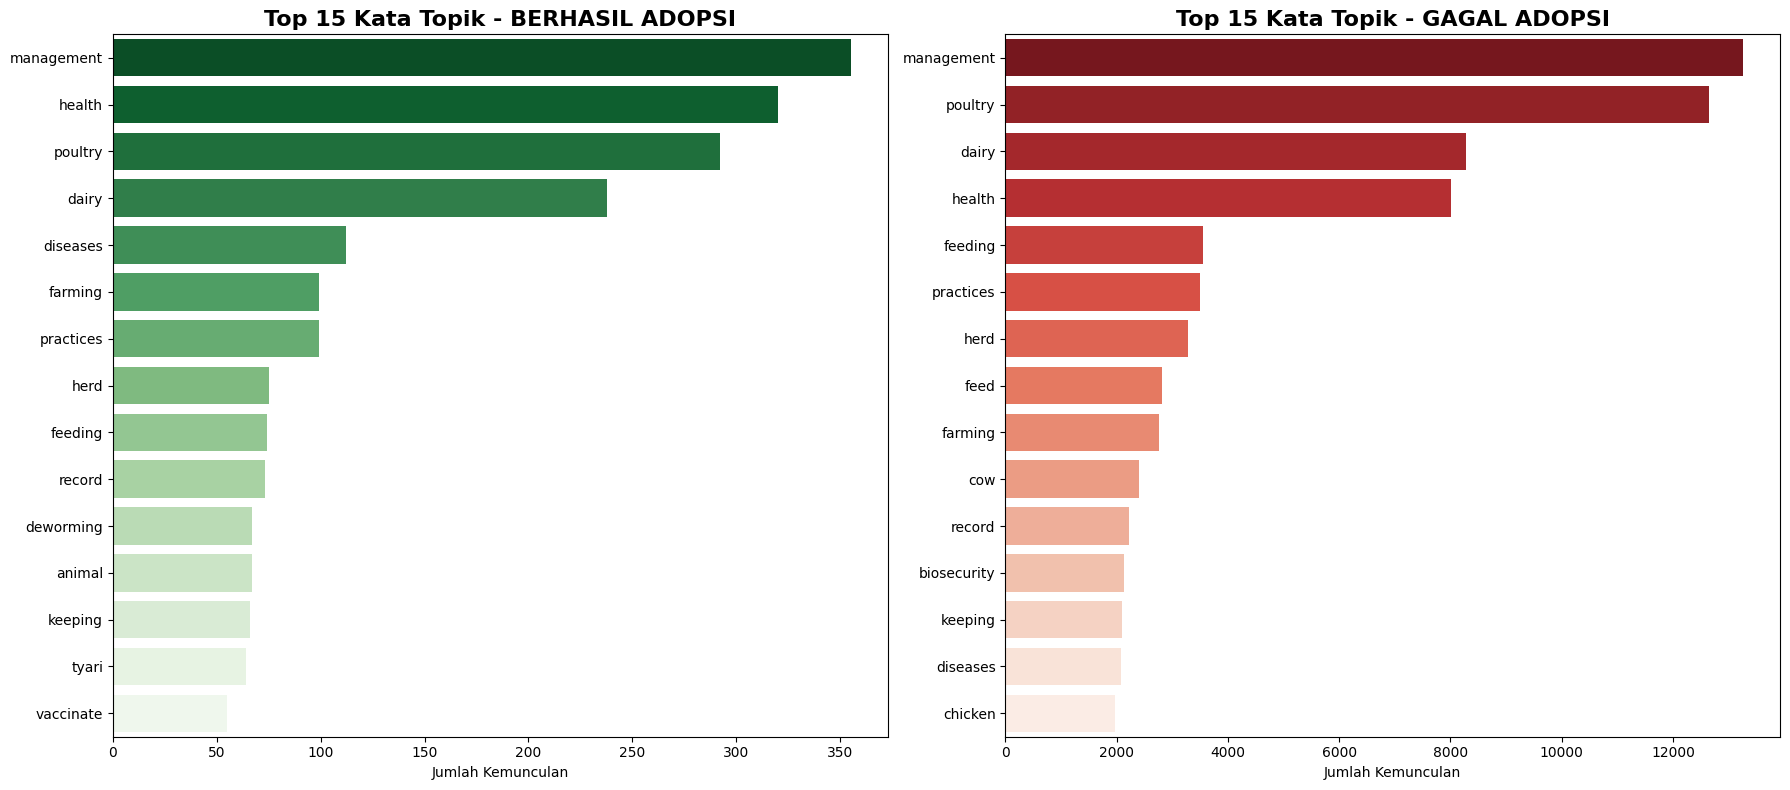

In [22]:
from collections import Counter

df_sukses = train_df[train_df['adopted_within_90_days'] == 1]
df_gagal = train_df[train_df['adopted_within_90_days'] == 0]
teks_sukses = " ".join(df_sukses['clean_topics'].astype(str))
teks_gagal = " ".join(df_gagal['clean_topics'].astype(str))

def dapatkan_kata_terbanyak(teks, jumlah=15):
    kata_kata = teks.split()
    hitung = Counter(kata_kata)
    return hitung.most_common(jumlah)

kata_sukses = dapatkan_kata_terbanyak(teks_sukses, 15)
kata_gagal = dapatkan_kata_terbanyak(teks_gagal, 15)

df_plot_sukses = pd.DataFrame(kata_sukses, columns=['Kata', 'Jumlah'])
df_plot_gagal = pd.DataFrame(kata_gagal, columns=['Kata', 'Jumlah'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=df_plot_sukses, x='Jumlah', y='Kata', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 15 Kata Topik - BERHASIL ADOPSI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Jumlah Kemunculan')
axes[0].set_ylabel('')

sns.barplot(data=df_plot_gagal, x='Jumlah', y='Kata', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 15 Kata Topik - GAGAL ADOPSI', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Jumlah Kemunculan')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

"management", "poultry", "dairy", dan "health". Empat kata ini di kelas Berhasil dan kelas Gagal. Berbahaya karena jumlah petani yang gagal itu belasan ribu, sedangkan yang berhasil hanya ratusan, kata "health" muncul 8.000 kali di data gagal, dan hanya 300 kali di data sukses. Jika CatBoost melihat kata "health", secara statistik ia akan langsung menebak "Gagal".

"deworming" (obat cacing), "tyari", dan "vaccinate" (vaksin).
Tiga kata ini masuk ke Top 15 kelas Sukses, tapi TIDAK ADA di Top 15 kelas Gagal. Ini membuktikan bahwa praktik medis spesifik dan tindakan fisik langsung adalah keberhasilan adopsi.

Kata "ndume" dan "app" tidak lagi masuk Top 15 karena kata-kata peternakan umum kini mendominasi grafik gagal. Namun, karena kita tahu dari WordCloud sebelumnya bahwa aplikasi digital sangat dibenci petani, kata tersebut tetap relevan sebagai sinyal bahaya, ditambah dengan munculnya "biosecurity" di grafik gagal yang mungkin dirasa terlalu rumit untuk diterapkan petani kecil.

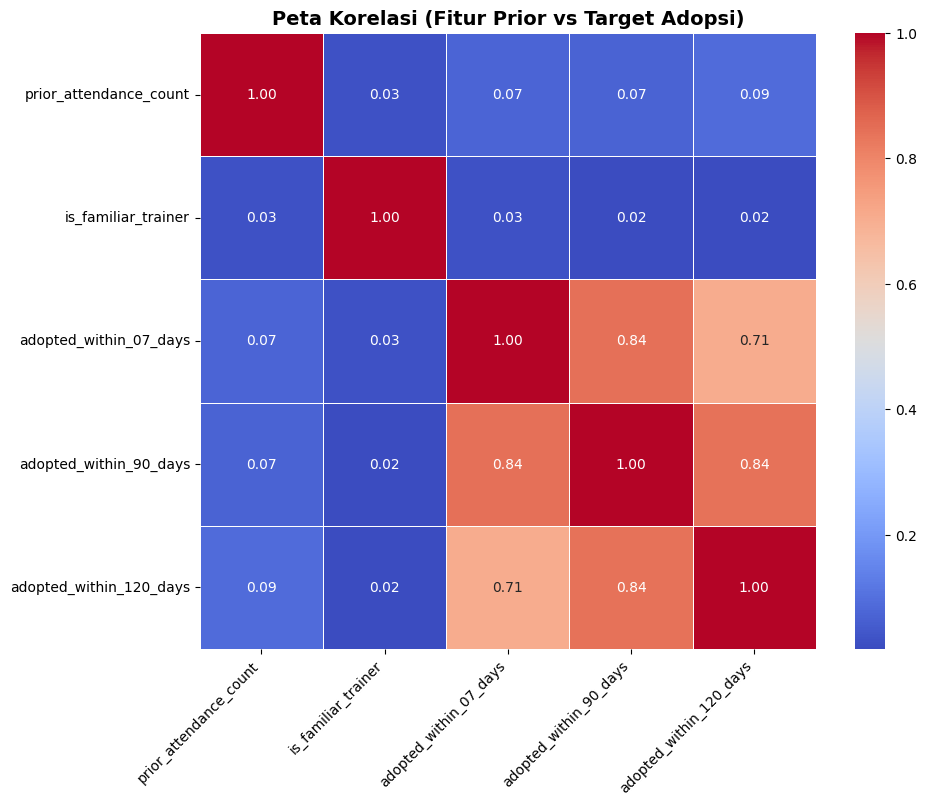

In [23]:
#NALISIS RIWAYAT MASA LALU
cols_to_check = [
    'prior_attendance_count', 'is_familiar_trainer',
    'adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days'
]

plt.figure(figsize=(10, 8))
#hitung matriks korelasi Pearson
corr_matrix = train_df[cols_to_check].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title('Peta Korelasi (Fitur Prior vs Target Adopsi)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

Korelasi antara adopted_within_07_days dan 90_days adalah 0.84.

prior_attendance_count dan is_familiar_trainer sekarang 100% mandiri dan memberikan informasi yang unik/berbeda kepada model tanpa tumpang tindih.

In [24]:
preprocess = ColumnTransformer( #proses teks and angka
    transformers=[
        ("cat", Pipeline(steps=[
            ("ohe",OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler())
        ]), num_cols)
    ]
)

In [25]:
cat_base = CatBoostClassifier(
    iterations=400,
    learning_rate=0.02,
    depth=4,
    auto_class_weights='Balanced',
    random_seed=SEED,
    verbose=0 
)

In [26]:
#kalibrasi probabilitas
calibrated_model = CalibratedClassifierCV(
    estimator=cat_base, 
    method='sigmoid',
    cv=5 
)

In [27]:
import warnings
warnings.filterwarnings('ignore')

targets = ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']

X_train_chained = X.copy()
X_test_chained = X_test_final.copy()
chained_features = []

#mengatur 5 Fold untuk Cross Validation
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for i, target in enumerate(targets):
    print("  Memproses target")
    y = train_df[target] #kunci jawaban
    
    #untuk menyimpan tebakan OOF (Out-of-Fold) dan Test
    oof_preds = np.zeros(len(X_train_chained))
    test_preds = np.zeros(len(X_test_chained))
    
    current_feature_cols = feature_cols + chained_features
    current_preprocess = ColumnTransformer(
        transformers=[
            ("cat", Pipeline(steps=[
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
            
            ("num", Pipeline(steps=[
                ("scaler", StandardScaler()) 
            ]), num_cols + chained_features) 
        ]
    )

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_chained, y)):
        print(f"  Melatih Fold {fold + 1}...")
        
        #memisahkan data berdasarkan index lipatan (Fold)
        X_tr = X_train_chained[current_feature_cols].iloc[train_idx]
        y_tr = y.iloc[train_idx]
        X_val = X_train_chained[current_feature_cols].iloc[val_idx]
        
        #inisialisasi ulang pipeline agar model benar-benar baru di tiap fold
        current_pipeline = Pipeline(steps=[
            ("preprocess", current_preprocess), 
            ("clf", calibrated_model)
        ])
        
        #latih model pada 4 bagian (80% data fold saat ini)
        current_pipeline.fit(X_tr, y_tr)
        
        #tebak 1 bagian sisanya (20% data validasi fold saat ini)
        oof_preds[val_idx] = current_pipeline.predict_proba(X_val)[:, 1]
        
        #tebak Test.csv, lalu bagi dengan jumlah fold untuk dirata-ratakan nanti
        test_preds += current_pipeline.predict_proba(X_test_chained[current_feature_cols])[:, 1] / N_SPLITS
    
    #menghitung Skor Validasi Keseluruhan (Dari 100% data Train yang ditebak secara jujur)
    val_auc = roc_auc_score(y, oof_preds)
    val_logloss = log_loss(y, oof_preds)
    print(f"K-Fold ROC-AUC  : {val_auc:.4f}")
    print(f"K-Fold Log-Loss : {val_logloss:.4f}")
    
    #simpan hasil tebakan ini sebagai fitur untuk Rantai Target berikutnya
    new_feat_name = f"pred_prob_{target}"
    X_train_chained[new_feat_name] = oof_preds  #hasil OOF murni, bukan hafalan
    X_test_chained[new_feat_name] = test_preds  #rata-rata 5 model
    
    chained_features.append(new_feat_name)

    #memasukkan tebakan akhir ke dalam file submission
    if '07' in target:
        submission['Target_07_AUC'] = test_preds
        submission['Target_07_LogLoss'] = test_preds
    elif '90' in target:
        submission['Target_90_AUC'] = test_preds
        submission['Target_90_LogLoss'] = test_preds
    elif '120' in target:
        submission['Target_120_AUC'] = test_preds
        submission['Target_120_LogLoss'] = test_preds

  Memproses target
  Melatih Fold 1...
  Melatih Fold 2...
  Melatih Fold 3...
  Melatih Fold 4...
  Melatih Fold 5...
K-Fold ROC-AUC  : 0.9504
K-Fold Log-Loss : 0.0422
  Memproses target
  Melatih Fold 1...
  Melatih Fold 2...
  Melatih Fold 3...
  Melatih Fold 4...
  Melatih Fold 5...
K-Fold ROC-AUC  : 0.9177
K-Fold Log-Loss : 0.0565
  Memproses target
  Melatih Fold 1...
  Melatih Fold 2...
  Melatih Fold 3...
  Melatih Fold 4...
  Melatih Fold 5...
K-Fold ROC-AUC  : 0.9137
K-Fold Log-Loss : 0.0735


In [28]:
kolom_final = [
    'ID', 
    'Target_07_AUC', 'Target_90_AUC', 'Target_120_AUC', 
    'Target_07_LogLoss', 'Target_90_LogLoss', 'Target_120_LogLoss'
]
submission.to_csv('1Submit.csv', index=False)
print("✅ Berhasil!")

✅ Berhasil!
